In [20]:
import pandas as pd              
import numpy as np          
import matplotlib.pyplot as plt    
import seaborn as sns 


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
dataset = pd.read_csv("C:\\Users\\khana\\Downloads\\car_price_dataset.csv")

In [23]:
dataset.head()

,Car_ID,Brand,Model_Year,Mileage_km,Engine_CC,Fuel_Type,Transmission,Car_Price_USD
0,1,Honda,2003,78216,3000,Diesel,Manual,16821
1,2,Toyota,2004,296755,1300,Electric,Automatic,57501
2,3,Kia,2013,151516,2000,Hybrid,Manual,76892
3,4,Hyundai,2020,231472,1000,Electric,Automatic,5287
4,5,Hyundai,2018,115546,1300,Petrol,Manual,74142


In [24]:
dataset.isnull().sum()

Car_ID           0
Brand            0
Model_Year       0
Mileage_km       0
Engine_CC        0
Fuel_Type        0
Transmission     0
Car_Price_USD    0
dtype: int64

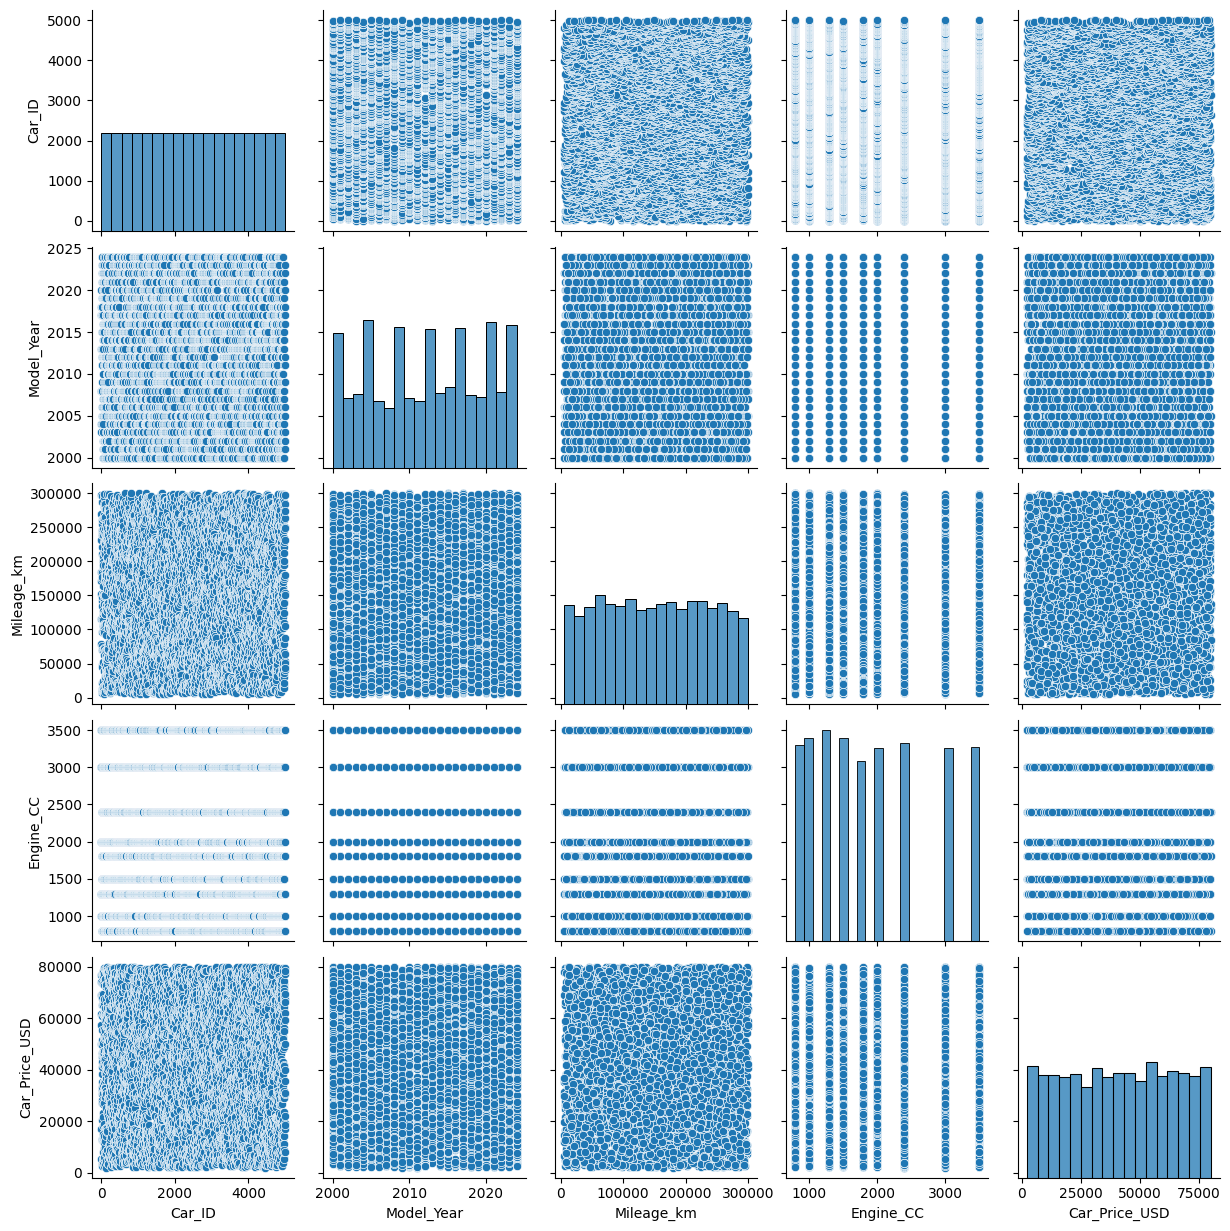

In [25]:
sns.pairplot(dataset)
plt.show()


In [26]:
dataset = dataset.drop("Car_ID", axis=1)
dataset = pd.get_dummies(dataset, drop_first=True)
print(dataset.head())

   Model_Year  Mileage_km  Engine_CC  Car_Price_USD  Brand_BMW  \
0        2003       78216       3000          16821      False   
1        2004      296755       1300          57501      False   
2        2013      151516       2000          76892      False   
3        2020      231472       1000           5287      False   
4        2018      115546       1300          74142      False   

   Brand_Chevrolet  Brand_Ford  Brand_Honda  Brand_Hyundai  Brand_Kia  \
0            False       False         True          False      False   
1            False       False        False          False      False   
2            False       False        False          False       True   
3            False       False        False           True      False   
4            False       False        False           True      False   

   Brand_Mercedes  Brand_Suzuki  Brand_Toyota  Fuel_Type_Electric  \
0           False         False         False               False   
1           False         

In [27]:
X = dataset.iloc[:,:-1]
y = dataset["Car_Price_USD"]


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
dataset.shape

(5000, 17)

In [30]:
X_train.shape

(4000, 16)

In [31]:
X_test.shape

(1000, 16)

In [32]:
y_train.shape

(4000,)

In [33]:
y_test.shape

(1000,)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)


In [36]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)*100

print("Mean Squared Error:", mse)
print("R2 Score:", r2, "%")

Mean Squared Error: 7.634233920938185e-22
R2 Score: 100.0 %


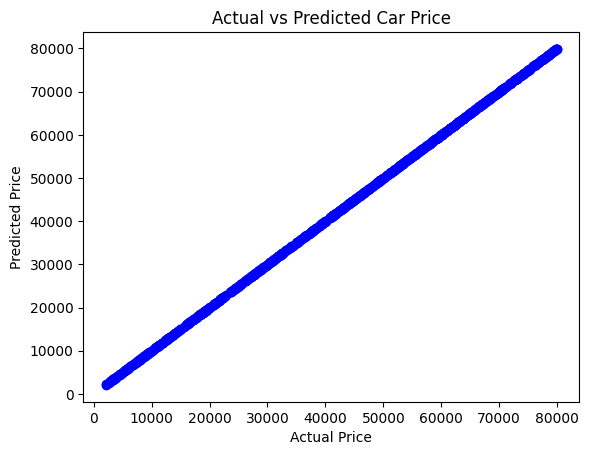

In [37]:
plt.scatter(y_test, y_pred, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()
